# Q3. The Role of Noise in Image Thresholding

**Objective:** Add zero-mean Gaussian noise with standard deviations of 10 and 50, compare intensity histograms, and study segmentation using one fixed global threshold.

**What does “clean grayscale” mean?** A grayscale image stores one brightness value per pixel (here, 0–255). “Clean” means no added noise; it does **not** mean blank, uniformly gray, or binary. Smooth shading and object boundaries are valid image content.

We use a recognizable, smoothly shaded **synthetic mug** on a dark background. It is an illustration, not a photograph. Creating it mathematically gives us a truly noiseless input and an exact foreground mask for evaluating segmentation. A photograph is also a grayscale image, but usually already contains some sensor noise.

**Run:** Execute all cells from top to bottom. Only NumPy and Matplotlib are required; no image downloads are needed.


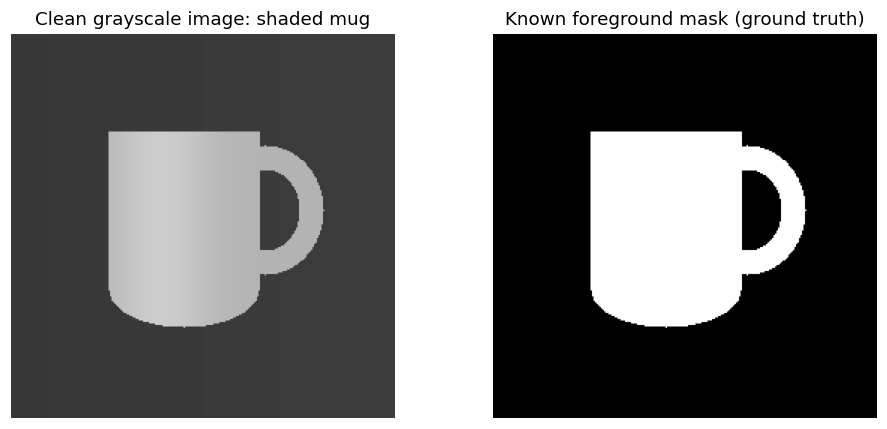

Clean image: (256, 256), uint8, 32 distinct gray levels


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A deterministic illustration: no random noise in the clean image.
# Smooth shading is image structure, not noise.
H, W = 256, 256
yy, xx = np.mgrid[:H, :W]
body = (xx >= 65) & (xx <= 165) & (yy >= 65) & (yy <= 170)
bottom = ((xx - 115) / 50) ** 2 + ((yy - 170) / 25) ** 2 <= 1
bottom &= yy >= 170
outer_handle = ((xx - 169) / 39) ** 2 + ((yy - 117) / 43) ** 2 <= 1
inner_handle = ((xx - 169) / 23) ** 2 + ((yy - 117) / 27) ** 2 < 1
handle = outer_handle & ~inner_handle & (xx >= 157)
foreground_mask = body | bottom | handle

background = 55 + 5 * xx / (W - 1)
object_shading = 180 + 25 * np.exp(-(((xx - 100) / 32) ** 2))
clean = np.rint(np.where(foreground_mask, object_shading, background)).astype(np.uint8)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(clean, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Clean grayscale image: shaded mug")
axes[1].imshow(foreground_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Known foreground mask (ground truth)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(
    f"Clean image: {clean.shape}, {clean.dtype}, {np.unique(clean).size} distinct gray levels"
)


## 1. Add Gaussian noise

$$I_{\mathrm{noisy}}(x,y) = I_{\mathrm{clean}}(x,y) + n(x,y), \qquad n(x,y) \sim \mathcal{N}(0,\sigma^2).$$

The standard deviation $\sigma$ is measured in gray levels on the 0–255 scale. We use $\sigma=10$ and $\sigma=50$, with a fixed random seed for reproducibility. Noise is added in floating point, then the result is clipped to [0, 255] and rounded before conversion to `uint8`.

The **sampled noise** has theoretical mean zero; a finite sample need not average to exactly zero. Clipping also changes the distribution of the final pixel differences and can produce histogram spikes at 0 and 255.


In [2]:
rng = np.random.default_rng(42)


def add_gaussian_noise(image, sigma, rng):
    noise = rng.normal(loc=0.0, scale=sigma, size=image.shape)
    raw = image.astype(np.float64) + noise
    clipped_fraction = np.mean((raw < 0) | (raw > 255))
    noisy = np.rint(np.clip(raw, 0, 255)).astype(np.uint8)
    print(
        f"σ={sigma:2}: sampled noise mean={noise.mean():.3f}, "
        f"std={noise.std():.3f}; clipped pixels={100 * clipped_fraction:.2f}%"
    )
    return noisy


noisy_10 = add_gaussian_noise(clean, 10, rng)
noisy_50 = add_gaussian_noise(clean, 50, rng)


σ=10: sampled noise mean=-0.015, std=10.028; clipped pixels=0.00%
σ=50: sampled noise mean=-0.291, std=50.184; clipped pixels=12.27%


## 2–3. Compare images, histograms, and global segmentation

Use the same fixed threshold **T = 128** for every image. Background values are 55–60 and foreground values are approximately 180–205, so 128 lies between the clean classes. Pixels greater than T are foreground (white); all other pixels are background (black).

The histograms below show the known background and foreground separately, so their overlap is visible. All images use the same 0–255 display scale and all histograms use the same intensity bins. Histogram heights scale independently by row to make broadening readable.


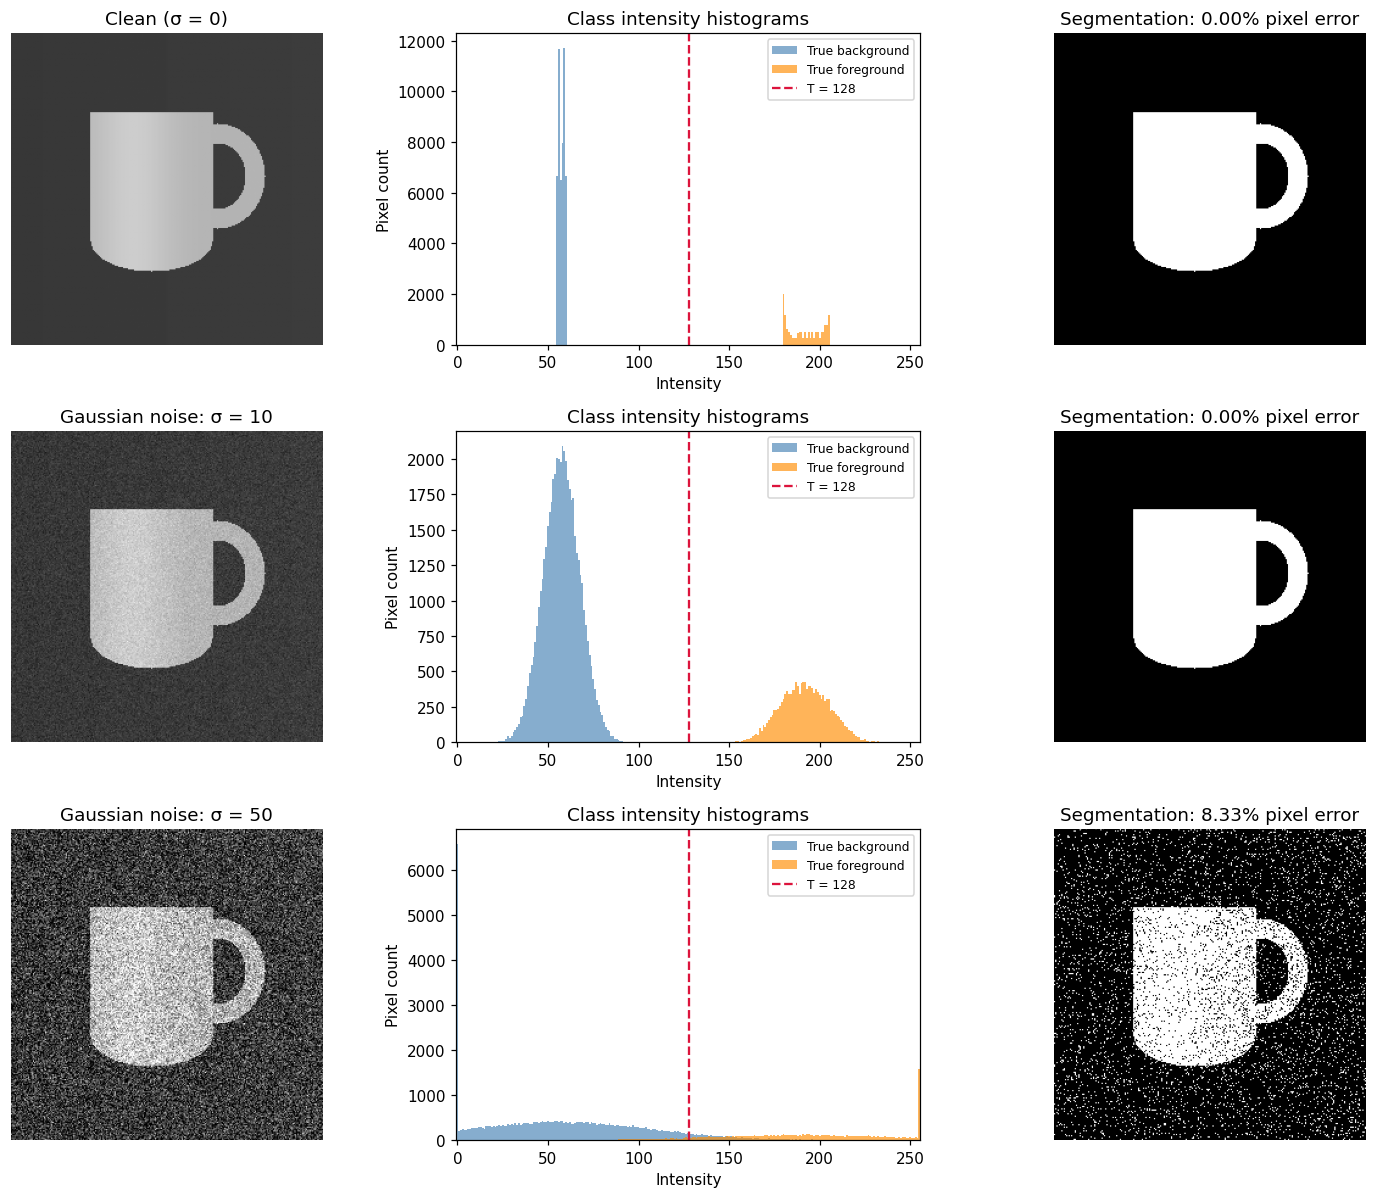

In [3]:
T = 128
images = [
    ("Clean (σ = 0)", clean),
    ("Gaussian noise: σ = 10", noisy_10),
    ("Gaussian noise: σ = 50", noisy_50),
]
bins = np.arange(257) - 0.5
binaries = []
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for row, (title, img) in enumerate(images):
    binary = img > T
    binaries.append(binary)
    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(title)
    axes[row, 0].axis("off")
    ax = axes[row, 1]
    ax.hist(
        img[~foreground_mask],
        bins=bins,
        color="steelblue",
        alpha=0.65,
        label="True background",
    )
    ax.hist(
        img[foreground_mask],
        bins=bins,
        color="darkorange",
        alpha=0.65,
        label="True foreground",
    )
    ax.axvline(T, color="crimson", linestyle="--", label=f"T = {T}")
    ax.set(
        xlim=(-0.5, 255.5),
        xlabel="Intensity",
        ylabel="Pixel count",
        title="Class intensity histograms",
    )
    ax.legend(fontsize=8)
    error = 100 * np.mean(binary != foreground_mask)
    axes[row, 2].imshow(binary, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"Segmentation: {error:.2f}% pixel error")
    axes[row, 2].axis("off")
plt.tight_layout()
plt.show()


## Quantitative comparison against the known object mask

The reference comes from the object geometry, independently of thresholding. **False positive rate** is the fraction of true background pixels marked foreground; **false negative rate** is the fraction of true foreground pixels missed. Overall pixel error uses all pixels as the denominator.


In [4]:
print(f'{"Image":<26} {"Pixel error":>13} {"False pos.":>13} {"False neg.":>13}')
for (title, _), binary in zip(images, binaries):
    error = np.mean(binary != foreground_mask)
    fp = np.mean(binary[~foreground_mask])
    fn = np.mean(~binary[foreground_mask])
    print(f"{title:<26} {error:>12.3%} {fp:>12.3%} {fn:>12.3%}")
assert np.array_equal(binaries[0], foreground_mask)


Image                        Pixel error    False pos.    False neg.
Clean (σ = 0)                    0.000%       0.000%       0.000%
Gaussian noise: σ = 10           0.000%       0.000%       0.000%
Gaussian noise: σ = 50           8.330%       7.792%      10.242%


## Discussion

- **Clean image:** The two intensity populations are separated by an empty interval. Thresholding recovers the exact mug mask, including its handle opening.
- **Low noise ($\sigma=10$):** The peaks broaden but remain well separated. This seeded example has no misclassified pixels; visible noise does not necessarily cause segmentation errors when the class contrast is large.
- **High noise ($\sigma=50$):** The distributions overlap near T. Background pixels cross above the threshold and object pixels cross below it, creating white speckles outside the mug and black holes inside it. These are classification errors caused by Gaussian noise, even though the binary output looks like salt-and-pepper noise.

Increasing noise reduces intensity-based class separation and makes a single threshold less reliable. The fixed threshold isolates the effect of noise; changing T cannot fully resolve overlapping classes. Denoising can reduce random fluctuations, with a trade-off in edge detail. Local thresholding is especially useful for uneven illumination and does not by itself eliminate strong random noise.
